Đang đọc dữ liệu...

THỐNG KÊ SỐ LƯỢNG NHÃN UIT-VSFC

[TRAIN] - Tổng: 11426 mẫu
  - Negative (0): 5325
  - Neutral  (1): 458
  - Positive (2): 5643

[DEV] - Tổng: 1583 mẫu
  - Negative (0): 705
  - Neutral  (1): 73
  - Positive (2): 805

[TEST] - Tổng: 3166 mẫu
  - Negative (0): 1409
  - Neutral  (1): 167
  - Positive (2): 1590

[TOÀN BỘ DATASET] - Tổng: 16175 mẫu
  - Negative (0): 7439
  - Neutral  (1): 698
  - Positive (2): 8038


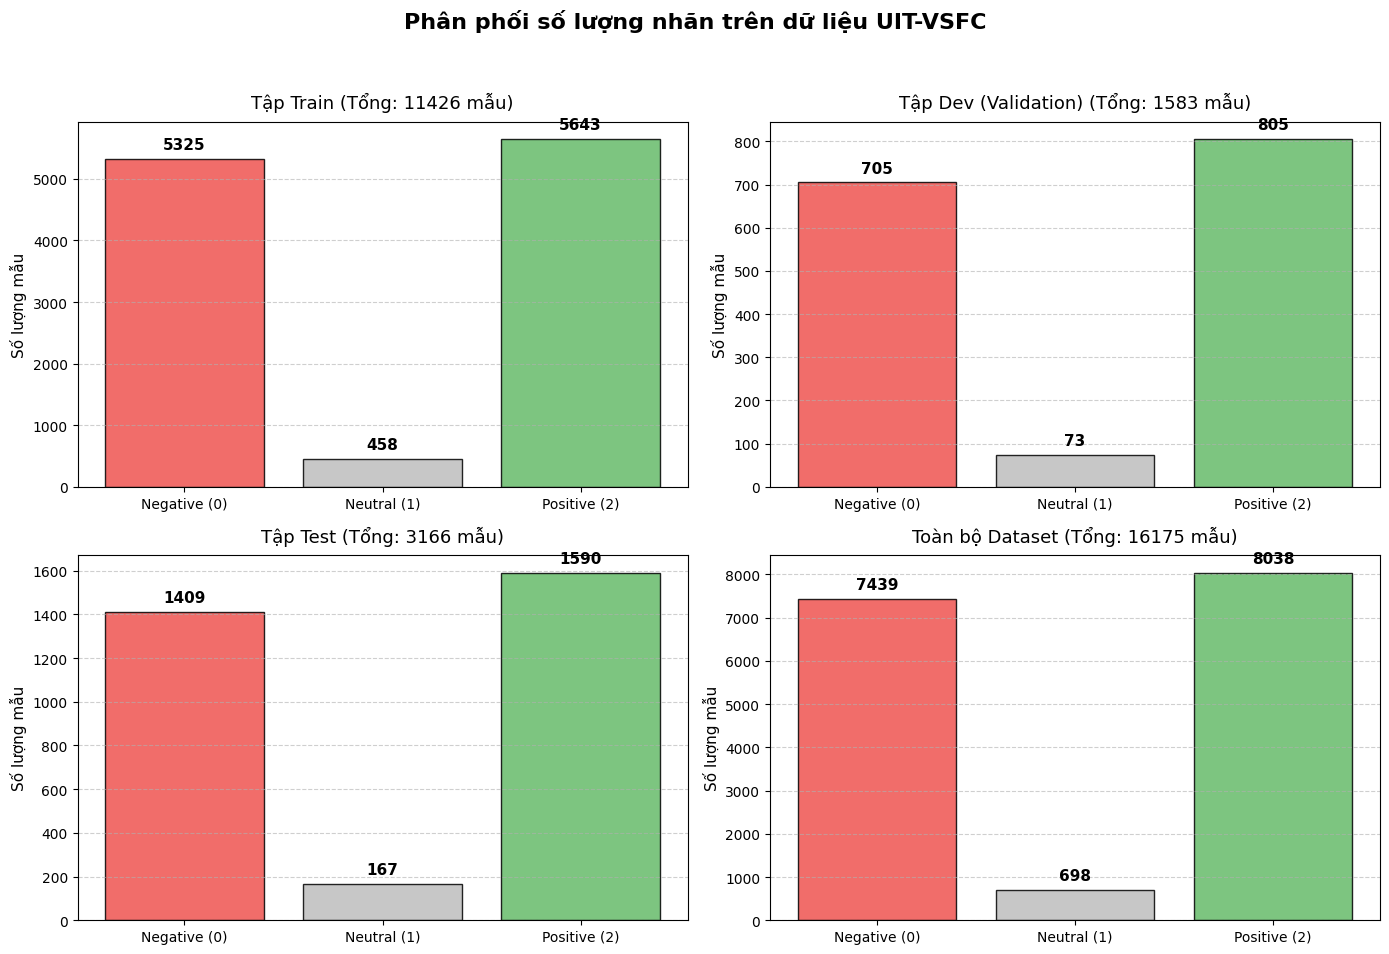

In [1]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# ==========================================
# 1. HÀM ĐỌC DỮ LIỆU TỪ FILE TXT
# ==========================================
def load_vsfc_labels(folder_path):
    """
    Chỉ đọc file sentiments.txt để lấy nhãn thống kê cho nhanh.
    Nếu bạn cần sents.txt, bạn có thể thêm lại như cũ.
    """
    file_path = os.path.join(folder_path, 'sentiments.txt')
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file tại: {file_path}")
        return []
        
    with open(file_path, 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
        
    return labels

# ==========================================
# 2. ĐỌC DỮ LIỆU TỪ 3 TẬP
# ==========================================
print("Đang đọc dữ liệu...")
train_path = '/kaggle/input/datasets/phamthinhzoro/uit-vsfc/new_data/train'
dev_path = '/kaggle/input/datasets/phamthinhzoro/uit-vsfc/new_data/dev'
test_path = '/kaggle/input/datasets/phamthinhzoro/uit-vsfc/new_data/test'

train_labels = load_vsfc_labels(train_path)
val_labels = load_vsfc_labels(dev_path)
test_labels = load_vsfc_labels(test_path)

all_labels = train_labels + val_labels + test_labels

# ==========================================
# 3. HÀM IN SỐ LIỆU VÀ VẼ BIỂU ĐỒ
# ==========================================
def plot_all_distributions(train_labels, val_labels, test_labels, all_labels):
    target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
    colors = ['#EF5350', '#BDBDBD', '#66BB6A'] # Đỏ, Xám, Xanh lá
    
    # --- IN SỐ LIỆU RA CONSOLE ---
    datasets_info = [
        ("TRAIN", train_labels),
        ("DEV", val_labels),
        ("TEST", test_labels),
        ("TOÀN BỘ DATASET", all_labels)
    ]
    
    print(f"\n{'='*40}")
    print("THỐNG KÊ SỐ LƯỢNG NHÃN UIT-VSFC")
    print(f"{'='*40}")
    
    for name, labels in datasets_info:
        counts = Counter(labels)
        print(f"\n[{name}] - Tổng: {len(labels)} mẫu")
        print(f"  - Negative (0): {counts[0]}")
        print(f"  - Neutral  (1): {counts[1]}")
        print(f"  - Positive (2): {counts[2]}")

    # --- VẼ BIỂU ĐỒ (Lưới 2x2) ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Phân phối số lượng nhãn trên dữ liệu UIT-VSFC', fontsize=16, fontweight='bold')
    
    # Ghép dữ liệu tương ứng với từng trục (axis) trong khung 2x2
    plot_data = [
        ('Tập Train', train_labels, axes[0, 0]),
        ('Tập Dev (Validation)', val_labels, axes[0, 1]),
        ('Tập Test', test_labels, axes[1, 0]),
        ('Toàn bộ Dataset', all_labels, axes[1, 1])
    ]
    
    for title, labels, ax in plot_data:
        counts = Counter(labels)
        y_values = [counts[0], counts[1], counts[2]]
        
        # Vẽ cột
        bars = ax.bar(target_names, y_values, color=colors, edgecolor='black', alpha=0.85)
        
        # Định dạng biểu đồ con
        ax.set_title(f'{title} (Tổng: {len(labels)} mẫu)', fontsize=13, pad=10)
        ax.set_ylabel('Số lượng mẫu', fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Thêm text số lượng lên đầu mỗi cột
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + max(y_values)*0.02, 
                    int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Tránh chữ đè lên suptitle
    plt.show()

# ==========================================
# 4. THỰC THI
# ==========================================
if len(all_labels) > 0:
    plot_all_distributions(train_labels, val_labels, test_labels, all_labels)
else:
    print("Vui lòng kiểm tra lại đường dẫn tới file dữ liệu!")